In [152]:
# Import from the landlab library
from landlab import RasterModelGrid, imshow_grid, imshowhs_grid
from landlab.plot import plot_graph
import numpy as np
import pandas as pd
import random as rng
import matplotlib.pyplot as plt
from matplotlib import cm
import matplotlib.colors as mcolors
import rioxarray
import csv

In [3]:
def surf_plot(grid, surface="topographic__elevation", units='m', title="Topographic Elevation (3D)", elev=20, azim=-150, ax=None, cmap="YlOrBr", vmin=None, vmax=None):
   
    single_fig = ax is None
    if single_fig:
        fig = plt.figure(figsize=(10, 6))
        ax = fig.add_axes([0.05, 0.05, 0.75, 0.90], projection="3d") # for some reason this plot cuts off the z-axis label for certain 
                                                                      # orientations (azim=-70) so this forces it to a specific position for some of them 
    else:
        fig = ax.get_figure()
    # plot the surface
    z = grid.at_node[surface].reshape(grid.shape)

    # Use provided vmin/vmax if given, otherwise fall back to this data's own min/max
    if vmin is not None:
        zmin = vmin
    else:
        zmin = z.min()
    if vmax is not None:
        zmax = vmax
    else:
        zmax = z.max()

    norm = mcolors.Normalize(vmin=zmin, vmax=zmax)
    surf = ax.plot_surface(
                grid.x_of_node.reshape(grid.shape),
                grid.y_of_node.reshape(grid.shape),
                z,
                cmap=cmap,
                norm=norm,
                linewidth=0.0,
                antialiased=False,
    )
    ax.view_init(elev=elev, azim=azim)
    ax.set_zlim(zmin, zmax)
    ax.set_xlabel(f"x [{units}]")
    ax.set_ylabel(f"y [{units}]")
    ax.set_zlabel(f"elevation [{units}]")
    plt.title(title)
    fig.colorbar(surf, ax=ax, label=f"elevation [{units}]")
    if single_fig:
        plt.show()

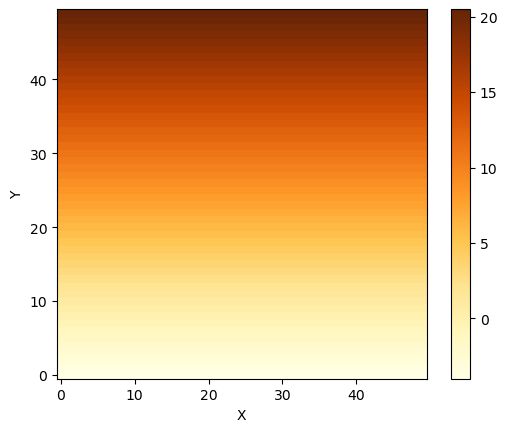

In [169]:
num_rows = 50  # number of grid rows
num_cols = 50  # number of grid columns
dxy = 1  # resolution of raster cell [m], or node horizontal and vertical spacing
grid = RasterModelGrid((num_rows, num_cols), dxy)

#create the initial simplified ramp topography
topo = grid.add_zeros('topographic__elevation', at='node')
cliff_height = -4 #working in meters
for i in range(num_rows):
    start = i * num_rows
    end = start + num_rows
    topo[start:end] = cliff_height
    cliff_height += 0.5
    
# Plot the topo map
imshow_grid(grid, "topographic__elevation",cmap="YlOrBr")

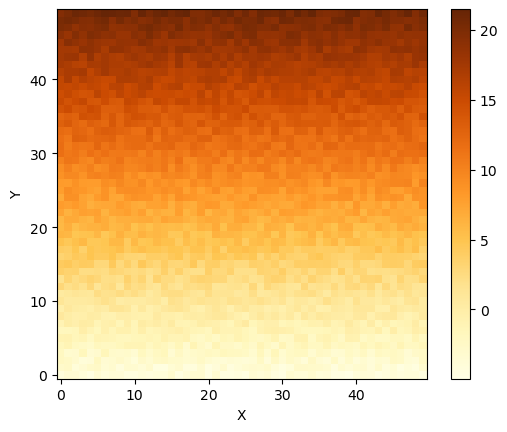

In [170]:
topo_noise = np.random.uniform(-1, 1, 2500)
topo += topo_noise

# Plot the topo map with noise
imshow_grid(grid, "topographic__elevation",cmap="YlOrBr")

In [171]:
#import csv files that contain the iccs sl projections for the future and noaa's reconstructed sl
sl_projection = pd.read_csv("projections_sea_level.csv")
sl_historic = pd.read_csv("noaa_paleo_sea_level.csv")

#convert column 'SeaLev_longPC1' to a NumPy array
sl_hist = sl_historic['SeaLev_longPC1'].to_numpy()

#convert row to NumPy array, ignoring the first 5 columns
sl_low = sl_projection.iloc[0,5:].to_numpy(dtype=float)
sl_med = sl_projection.iloc[1,5:].to_numpy(dtype=float)
sl_high = sl_projection.iloc[2,5:].to_numpy(dtype=float)
sl_extreme = sl_projection.iloc[3,5:].to_numpy(dtype=float)
#sl_idealized = np.array(10,-5,1000)

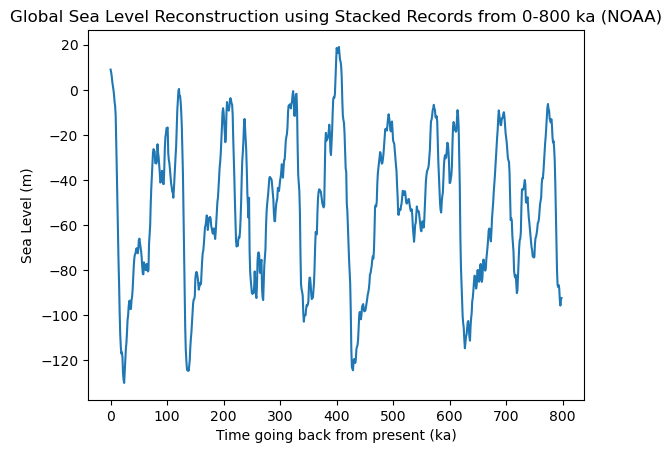

In [172]:
#plot sea level
sl_historic["SeaLev_longPC1"].plot(kind="line")
plt.title("Global Sea Level Reconstruction using Stacked Records from 0-800 ka (NOAA)")
plt.xlabel("Time going back from present (ka)")
plt.ylabel("Sea Level (m)")
plt.show()

#### Projected Sea Level Rise Under Different SSP Scenarios (IPCC & NOAA)
![noaa sea level](sea_level_proj.png)

In [173]:
#parameters for future projections
sea_level = 6.0 #meters
start_year = 2020
erosion_rate = 0.002  #m/y or set zr[i] = sea_level to cut/flatten directly
uplift_rate_m_yr = 2.1/1000 #2.1 mm/yr avg uplift (0.0021 m/yr)
dt = 1 # timestep (yr)
uplift = uplift_rate_m_yr * dt
erosion_depth = erosion_rate * dt
time_to_run = 130  # time for the model loop to run [yr]
nsteps = int(time_to_run / dt)  # number of model time steps
plot_interval = 200    # how often (in years) to print progress and plot

In [174]:
#parameters for historic runs
sea_level = 20.0 #meters
erosion_rate = 0.002  #m/y or set zr[i] = sea_level to cut/flatten directly
uplift_rate_m_yr = 2.1/1000 #2.1 mm/yr avg uplift (0.0021 m/yr)
dt = 100 # timestep (yr)
uplift = uplift_rate_m_yr * dt
erosion_depth = erosion_rate * dt
time_to_run = 200000  # time for the model loop to run [yr]
nsteps = int(time_to_run / dt)  # number of model time steps
plot_interval = 200    # how often (in years) to print progress and plot

In [161]:
for step in range (1001):
    if step % plot_interval == 0:
        print(step)

0
200
400
600
800
1000


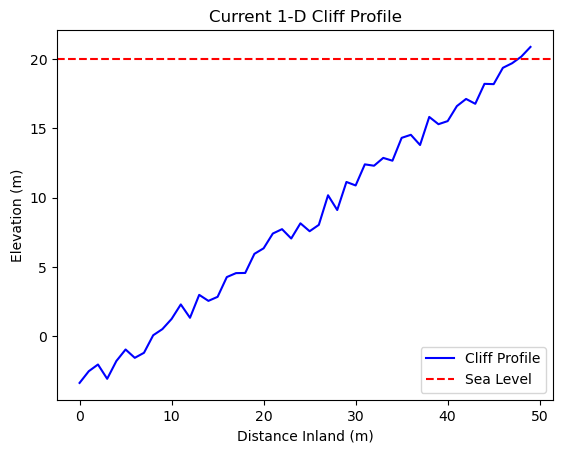

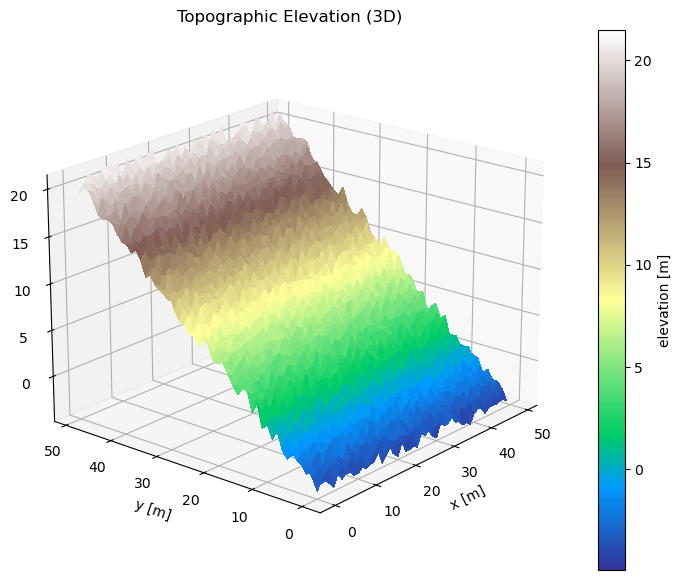

In [175]:
xnode_filter = np.isclose(grid.x_of_node, 5.0)
# Extract all values at that x-position for a specific field
values_at_x = grid.at_node['topographic__elevation'][xnode_filter]
plt.plot(values_at_x, color='blue', label='Cliff Profile')
plt.axhline(sea_level, color='red', linestyle='--', label='Sea Level')
plt.xlabel("Distance Inland (m)")
plt.ylabel("Elevation (m)")
plt.title("Current 1-D Cliff Profile")
plt.legend()
plt.show()
surf_plot(grid, azim=220,cmap='terrain', vmin=min(topo), vmax=max(topo))

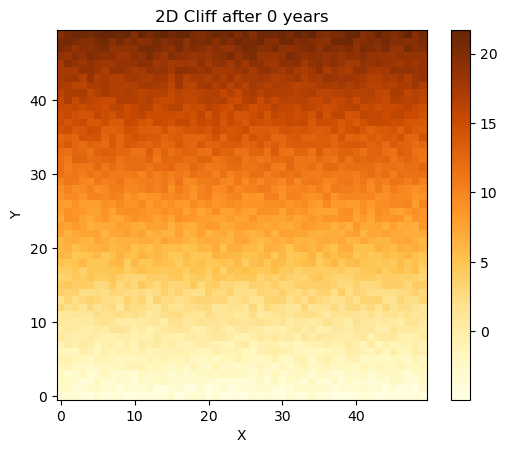

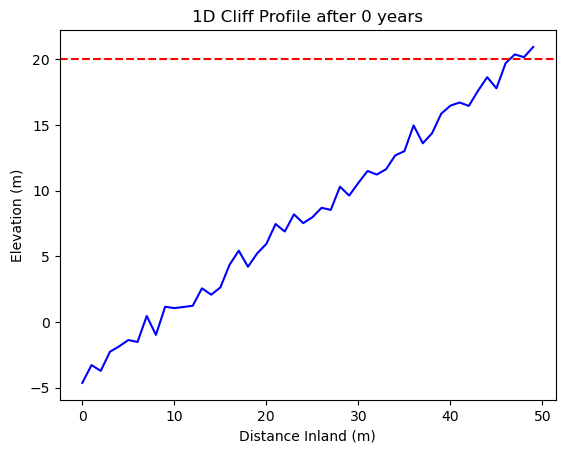

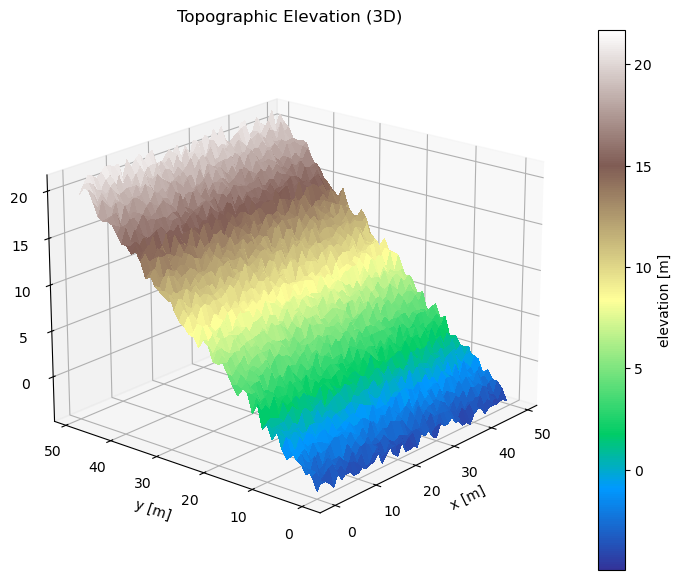

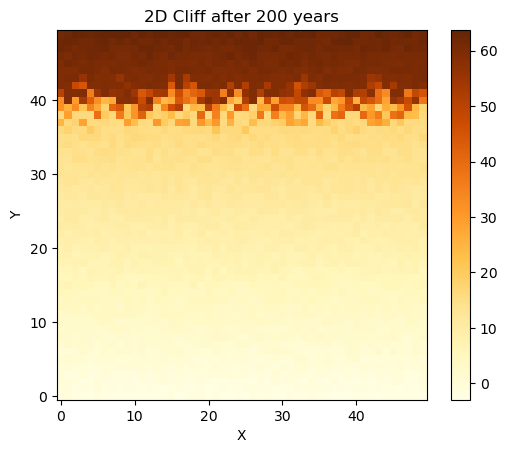

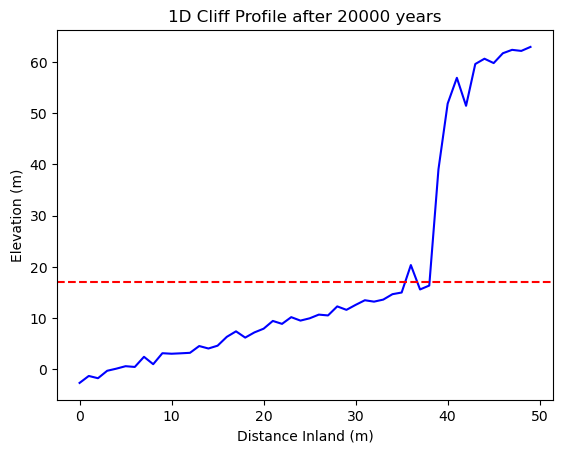

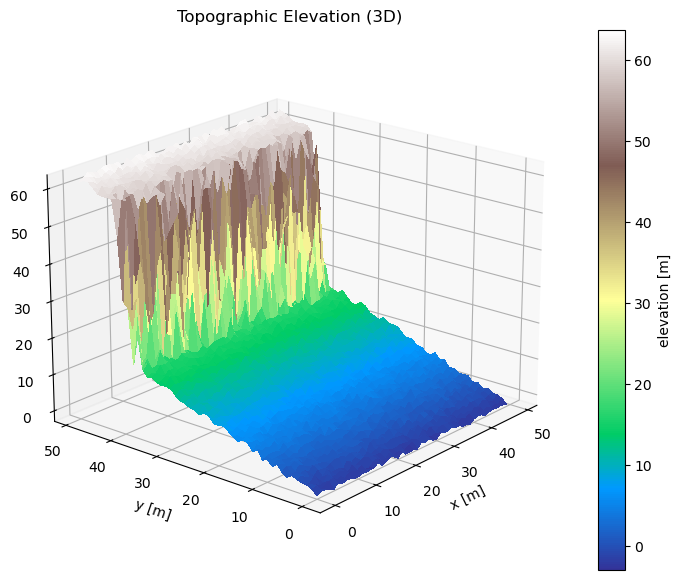

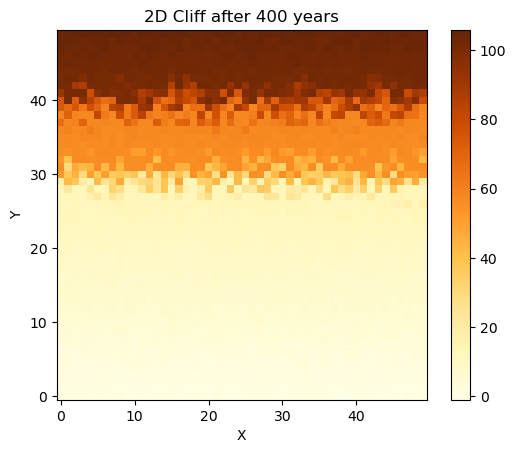

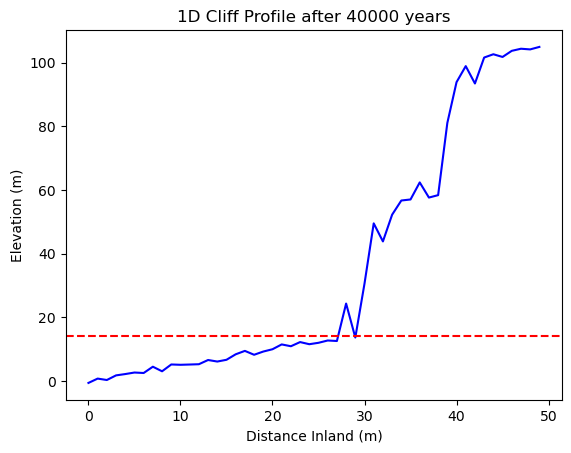

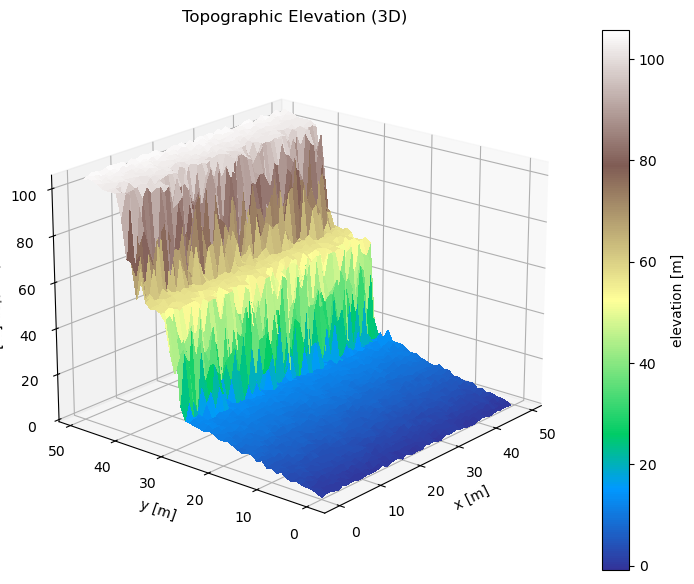

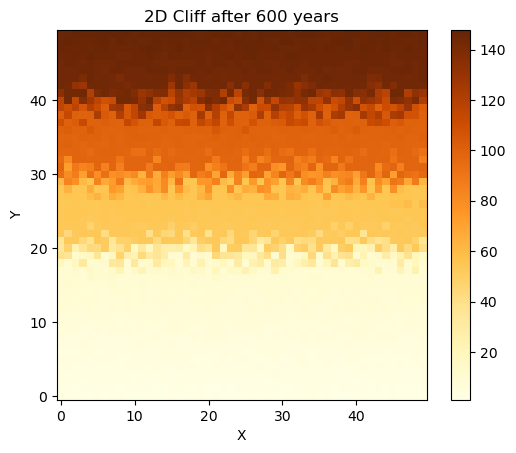

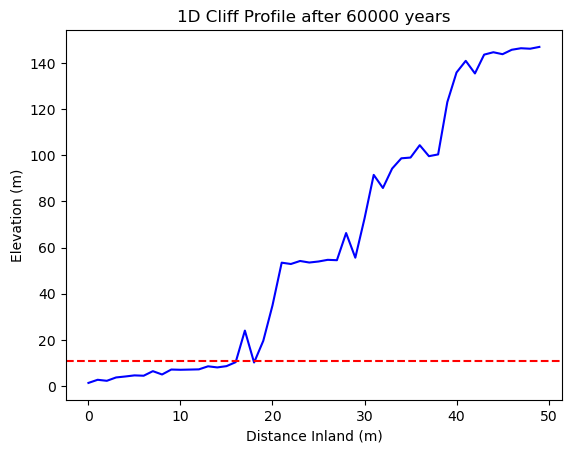

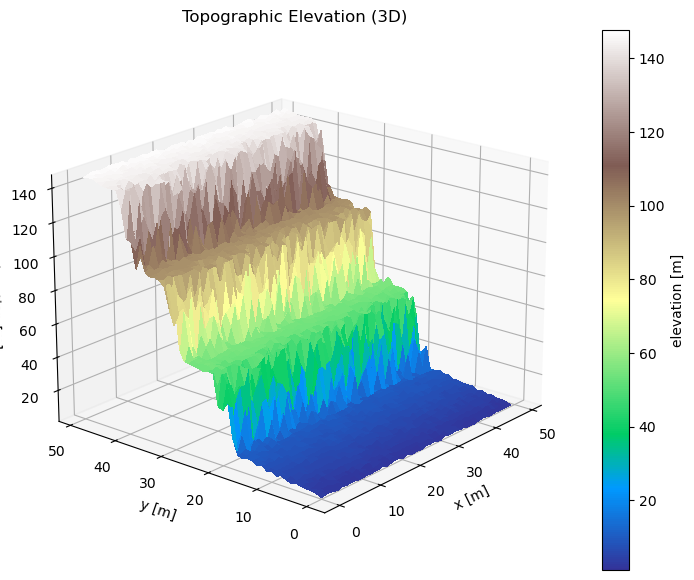

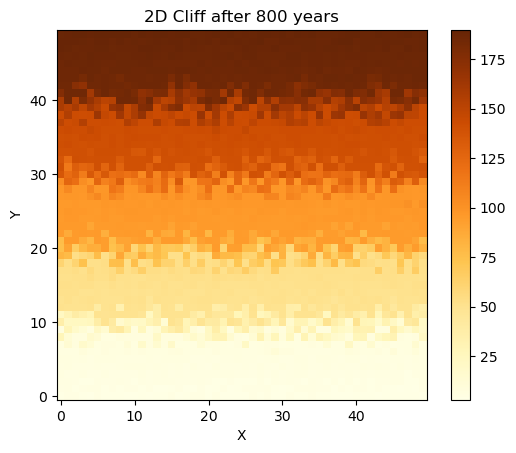

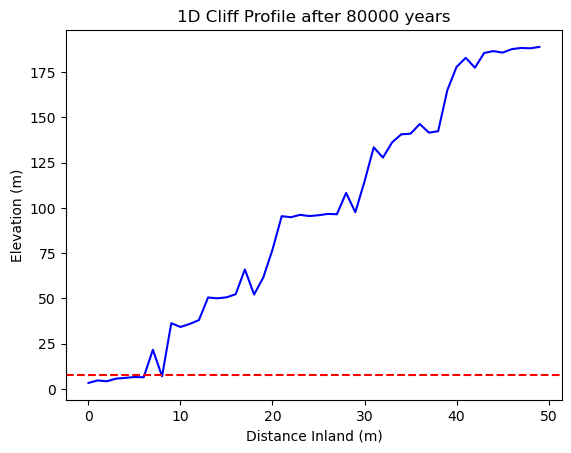

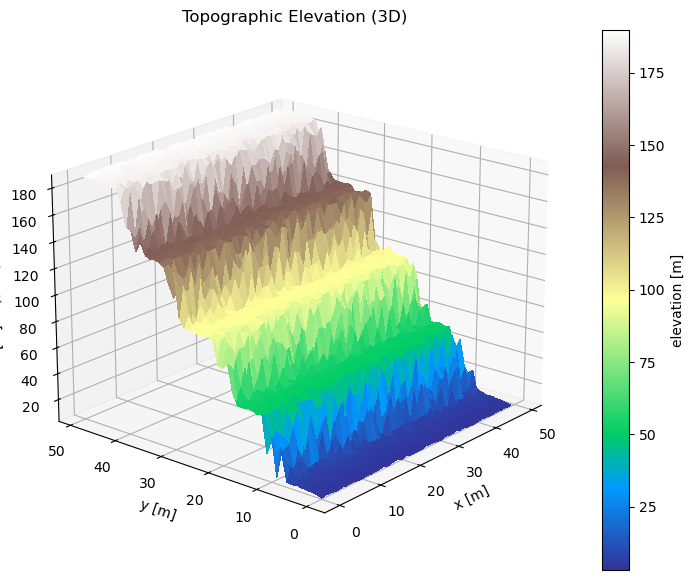

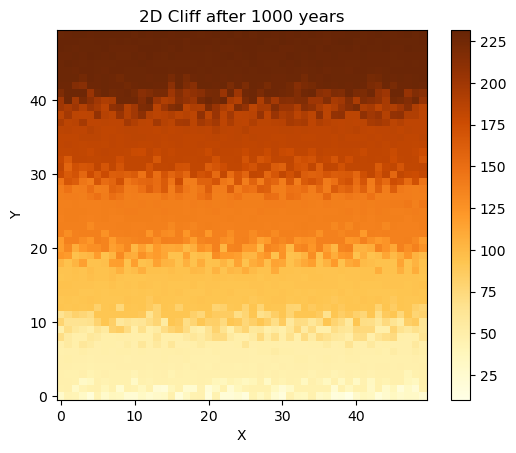

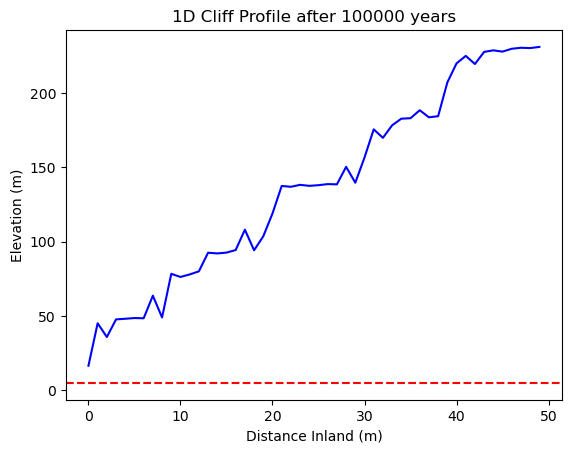

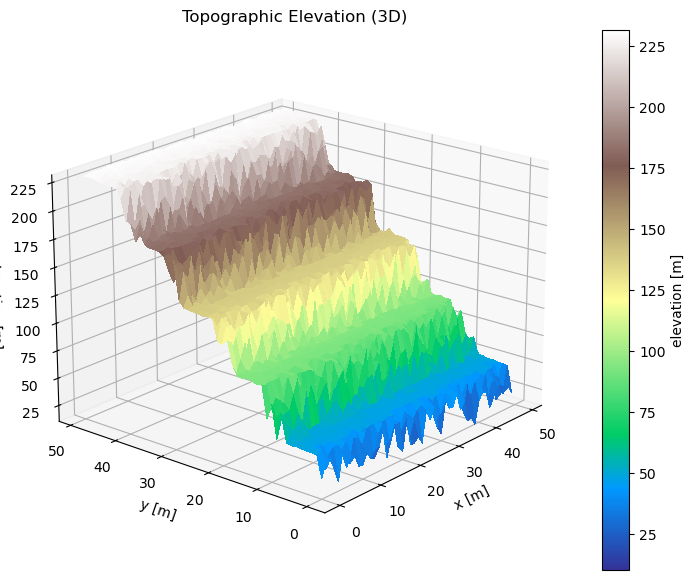

In [176]:
for step in range (1001):
    # Loop over every node on the grid (removed the + 1)
    for i in range(grid.number_of_nodes):
        topo[i]+= uplift
        if topo[i] < sea_level:
            topo[i] -= erosion_depth  # Erode node if it is underwater
    # plot at the plot_interval to show the current state of hte hillslope
    if step % plot_interval == 0:
        imshow_grid(grid, "topographic__elevation",cmap="YlOrBr")
        plt.title(f'2D Cliff after {step} years')
        plt.show()

        xnode_filter = np.isclose(grid.x_of_node, 25.0)
        # Extract all values at that x-position for a specific field
        values_at_x = grid.at_node['topographic__elevation'][xnode_filter]
        plt.plot(values_at_x, color='blue', label='Cliff Profile')
        plt.axhline(sea_level, color='red', linestyle='--', label='Sea Level')
        plt.title(f'1D Cliff Profile after {step*dt} years')
        plt.xlabel("Distance Inland (m)")
        plt.ylabel("Elevation (m)")
        plt.show()
        
        surf_plot(grid, azim=220,cmap='terrain', vmin=min(topo), vmax=max(topo))
        sea_level -= 3

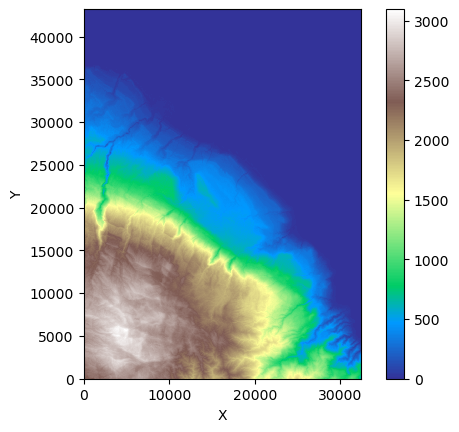

In [111]:
dem = rioxarray.open_rasterio("dem_clipped.tif",masked=True).squeeze()
clipped_dem = dem.rio.clip_box(minx=147.4, miny=-6.3, maxx=147.7, maxy=-5.9)
clipped_dem.rio.to_raster("dem_clipped.tif")
dem_array = clipped_dem.values.astype(float)

if clipped_dem.y[0] > clipped_dem.y[-1]:
    dem_array = np.flipud(dem_array)

num_rows, num_cols = dem_array.shape 
dxy = 30

grid = RasterModelGrid((num_rows, num_cols),dxy)

topo = grid.add_field("topographic__elevation", dem_array.ravel(), at="node")

imshow_grid(grid, topo, cmap="terrain")
plt.show()

In [112]:
## variable uplift rates (trial)
sea_level = 6.0
erosion_rate = 0.5

y = grid.y_of_node

uplift_rate_m_yr = np.zeros(grid.number_of_nodes)

uplift_rate_m_yr[(y >= 0)     & (y < 5000)]  = 3.5 / 1000
uplift_rate_m_yr[(y >= 5000)  & (y < 10000)] = 3.25 / 1000
uplift_rate_m_yr[(y >= 10000) & (y < 15000)] = 3 / 1000
uplift_rate_m_yr[(y >= 15000) & (y < 20000)] = 2.75 / 1000
uplift_rate_m_yr[(y >= 20000) & (y < 25000)] = 2.5 / 1000
uplift_rate_m_yr[(y >= 25000) & (y < 30000)] = 2.25 / 1000
uplift_rate_m_yr[y >= 30000] = 2 / 1000

dt = 1000
uplift = uplift_rate_m_yr * dt

time_to_run = 1e6
nsteps = int(time_to_run / dt)

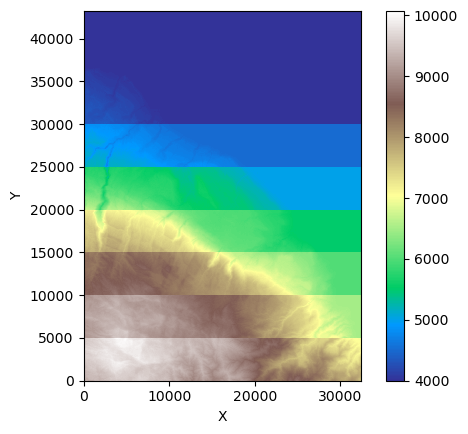

In [115]:
for step in range(nsteps):
    topo += uplift
    is_wet = np.where(topo < sea_level, 1, 0) # Create a vector showing which nodes are below sea level
    topo -= erosion_rate * is_wet # Erode the nodes that are below sea level

# Plotting
imshow_grid(grid, "topographic__elevation",cmap="terrain")